In [22]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from utils import *

In [23]:
def solver_name_to_precision(name):
    asm_prec = name.split(".")[1].split(",")[0]
    if "Inv(torch." not in name:
        return asm_prec
    else:
        inv_prec = name.split("Inv(torch.")[1].split(")")[0]
        return f"{asm_prec}+{inv_prec}"

In [24]:
def process_experiments_df(df: pd.DataFrame):
    if "solve time" not in df.columns:
        return pd.DataFrame()

    df = df.copy()
    metadata_df = df.apply(extract_row_metadata, axis=1)
    metadata_cols = metadata_df.columns.tolist()
    df = pd.concat([df, metadata_df], axis=1)

    df["precision"] = df["solver"].apply(solver_name_to_precision)
    pivot_table = df.pivot_table(
        index=["p", "fine m", "coarse m"],
        columns=["precision"],
        values=metadata_cols,
        aggfunc="min",
    )
    return pivot_table

In [25]:
df = pd.read_csv("../results/experiment_precisions.csv")

In [26]:
summary = process_experiments_df(df)
summary

asm setup time                                   \
precision                float32 float32+bfloat16 float32+float16   
p fine m coarse m                                                   
1 10     8           1483.516968      1419.679688     1458.738159   
         9           2411.042725      2172.028809     2239.411133   
         10          5268.392090      5260.703613     5348.182129   
3 9      7           1744.404541      1638.171631     1547.494385   
         8           1714.889771      1686.587402     1656.690674   
         9           2595.809326      2562.078613     2607.165527   
5 8      6           1921.251343      1744.921631     1740.452881   
         7           1558.672363      1537.509399     1521.852417   
         8           1775.072266      1769.459717     1741.789185   

                                 asm time                                   \
precision              float64    float32 float32+bfloat16 float32+float16   
p fine m coarse m                                                            
1 10     8         1627.611084   2.191790         1.900503        1.878057   
         9         2498.286621   4.177613         4.094566        4.096840   
         10        5394.994141  14.144532        14.156370       14.148895   
3 9      7         2159.824951   2.767688         2.012078        1.984123   
         8         1872.061401   2.082345         1.887539        1.872118   
         9         2688.438232   4.421304         4.368671        4.369818   
5 8      6         2382.915527   2.836132         1.862410        1.888195   
         7         1664.521240   1.214464         0.996659        0.986583   
         8         1871.802368   1.629737         1.574298        1.572823   

                             cg setup time                   ...  \
precision            float64       float32 float32+bfloat16  ...   
p fine m coarse m                                            ...   
1 10     8          3.140792   1236.556763      1217.441772  ...   
         9          4.807352   1758.819336      1798.147095  ...   
         10        15.758315   3549.781982      3600.518066  ...   
3 9      7          4.704379   1393.903564      1378.786255  ...   
         8          2.799247   1515.324463      1527.842773  ...   
         9          5.102039   2144.568359      2238.131104  ...   
5 8      6          4.711055   1464.601562      1496.294434  ...   
         7          1.816084   1472.158691      1546.811401  ...   
         8          1.989427   1696.571411      1798.091797  ...   

                       iterations         local solvers setup time  \
precision         float32+float16 float64                  float32   
p fine m coarse m                                                    
1 10     8                   75.0    75.0               241.911621   
         9                   55.0    55.0               184.335617   
         10                  45.0    45.0               134.749725   
3 9      7                  219.0   219.0               435.886749   
         8                  154.0   153.0               288.731995   
         9                  108.0   107.0               230.315903   
5 8      6                  369.0   364.0               559.904541   
         7                  256.0   256.0               351.052307   
         8                  178.0   178.0               283.220032   

                                                                \
precision         float32+bfloat16 float32+float16     float64   
p fine m coarse m                                                
1 10     8              246.349823      248.477692  245.854523   
         9              181.359619      174.872574  189.371353   
         10             140.897278      146.394119  143.881790   
3 9      7              437.136383      433.038330  509.743134   
         8              289.814514      286.896118  301.516846   
         9              230.923264      230.391815  238.096130   


In [27]:
precisions = ["float64", "float32", "float32+float16", "float32+bfloat16"]
ps = [1, 3, 5]


def shorten_precision(prec):
    return "+".join(
        [("fp" if p.startswith("f") else "bf") + p[-2:] for p in prec.split("+")]
    )

## Sanity check

p=1, slope: 1.0538635381971473, intercept: -0.7156751378626893
p=3, slope: 1.6232311110061197, intercept: 5.246758739616382
p=5, slope: 1.6057799835807773, intercept: -16.066752469484072


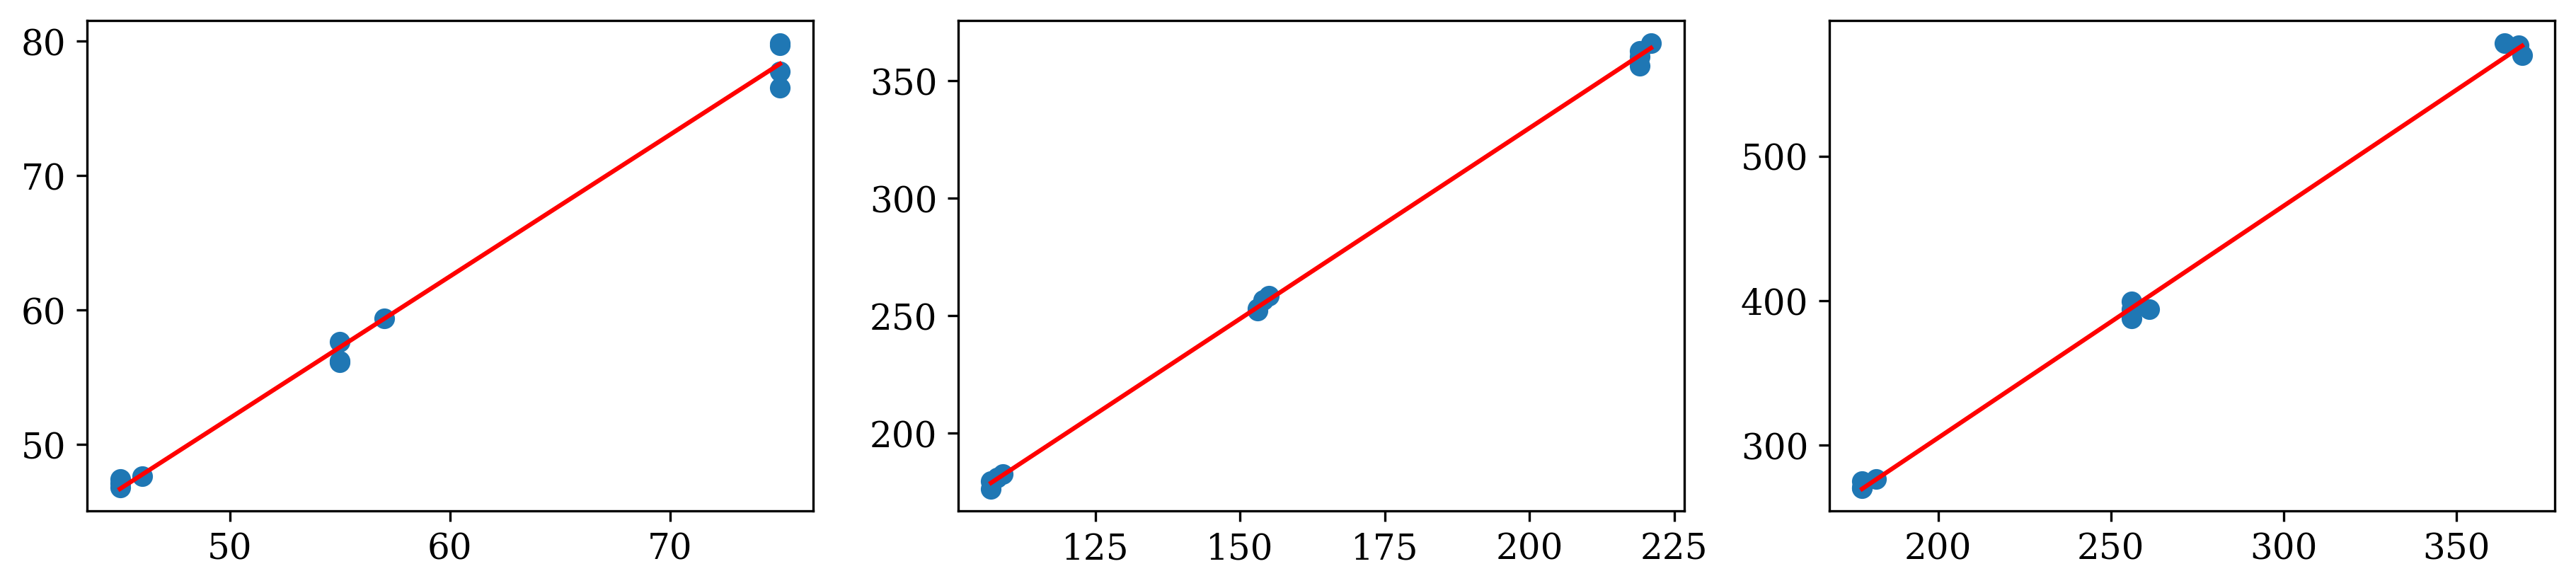

In [28]:
from sklearn.linear_model import LinearRegression

fig, axes = plt.subplots(1, 3, figsize=(15, 3), dpi=300)
for i, p in enumerate([1, 3, 5]):
    sp = summary.xs(p, level="p")
    iters = sp["iterations"].values.flatten()
    cg_time = (sp["cg time"] - sp["asm time"] * sp["iterations"]).values.flatten()
    cg_time = cg_time[iters < 600]
    iters = iters[iters < 600]
    axes[i].scatter(iters, cg_time)

    model = LinearRegression().fit(iters.reshape(-1, 1), cg_time)
    print(f"p={p}, slope: {model.coef_[0]}, intercept: {model.intercept_}")

    itx = np.linspace(iters.min(), iters.max(), 100).reshape(-1, 1)
    predicted = model.predict(itx)
    axes[i].plot(itx, predicted, color="red", label="Linear fit")

## Iteration count table

In [29]:
nice_col_names = {
    "p": "$p$",
    "fine m": "$m$",
    "solvers m": "$M$",
    "coarse m": "$\\mathcal{M}$",
}

iter_summary = summary["iterations"][precisions].copy()
formatted_iter_table = iter_summary.astype(int).style.format_index(
    lambda prec: f"{{\\texttt{{{shorten_precision(prec)}}}}}",
    axis=1,
)
formatted_iter_table.index.rename(nice_col_names, inplace=True)
formatted_iter_table.columns.name = None


def highlight_values(s):
    return [""] + [
        "color: #ff0000;" if v > 500 else "color: #aaaaaa" if v == s.iloc[0] else ""
        for v in s[1:]
    ]


formatted_iter_table = formatted_iter_table.apply(highlight_values, axis=1)

formatted_iter_table

In [30]:
iter_table_latex = formatted_iter_table.to_latex(
    hrules=True,
    multirow_align="t",
    column_format="rrr|" + 4 * "S[table-format=3, table-column-width=4.3em]",
    convert_css=True,
)
latex_lines = iter_table_latex.split("\n")
first_header_line = latex_lines.index("\\toprule") + 1
last_header_line = latex_lines.index("\\midrule") - 1
column_names = [None] * len(latex_lines[first_header_line].split("&"))
for line in latex_lines[first_header_line : last_header_line + 1]:
    line_col_names = [x.strip().removesuffix("\\\\") for x in line.split("&")]
    for i, col_name in enumerate(line_col_names):
        if col_name:
            column_names[i] = col_name
single_header_line = " & ".join(column_names) + " \\\\"
hacked_pivot_latex = "\n".join(
    latex_lines[:first_header_line]
    + [single_header_line]
    + latex_lines[last_header_line + 1 :]
)
with open("../docs/tables/experiment_precision_iterations.tex", "w") as f:
    f.write(hacked_pivot_latex)

## Plots

In [31]:
def get_plot_df(p: int, prec: int):
    data = (
        summary.xs(p, level="p")
        .xs(prec, level="precision", axis=1)
        .reset_index()
        .set_index("coarse m")
    )
    total_local_solvers = "local solvers"
    total_coarse_solver = "coarse solver"
    # total_asm_rest = "$R_C$, $R_C^T$, type casts"
    total_asm_rest = "other ASM components"
    total_not_asm = "outer PCG"
    data[total_local_solvers] = data["local solvers time"] * data["iterations"]
    data[total_coarse_solver] = data["coarse solver time"] * data["iterations"]
    data[total_asm_rest] = (
        data["asm time"] - data["local solvers time"] - data["coarse solver time"]
    ) * data["iterations"]
    data[total_not_asm] = (
        data["cg time"]
        - data[total_asm_rest]
        - data[total_coarse_solver]
        - data[total_local_solvers]
    )
    to_plot = (
        data[[total_not_asm, total_asm_rest, total_coarse_solver, total_local_solvers]]
        / 1000
    )
    return to_plot

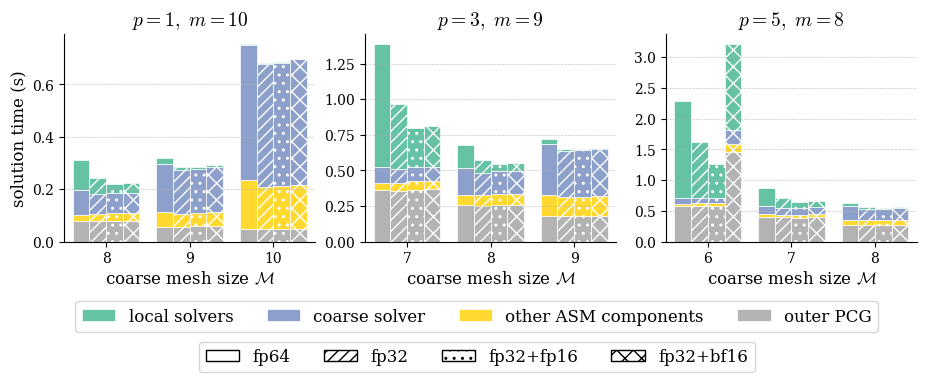

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(11, 2.7))
# ['//', '\\\\', '--', 'xx', '..']
hatch_list = ["", "///", "..", "xx"]
for ax, p in zip(axes, ps):
    plot_clustered_stacked(
        ax,
        [get_plot_df(p, prec) for prec in precisions],
        precisions,
        hatch_list=hatch_list,
        add_legend=False,
    )
    m = summary.xs(p, level="p").index.get_level_values(0)[0]
    ax.set_title(f"$p={p},\\ m={m}$")
    ax.set_xlabel("coarse mesh size $\\mathcal{M}$")
    if p == 1:
        ax.set_ylabel("solution time (s)")
    ax.tick_params(axis="both", which="major", labelsize=10)
    ax.tick_params(axis="both", which="minor", labelsize=8)

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles[::-1],
    labels[::-1],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncols=4,
)

proxies = []
for i, prec in enumerate(precisions):
    p = mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        hatch=hatch_list[i] or "",
        # alpha=alpha_list[i],
        label=prec,
    )
    proxies.append(p)
fig.legend(
    proxies,
    map(shorten_precision, precisions),
    loc="upper center",
    bbox_to_anchor=(0.5, -0.23),
    ncols=4,
)
fig.savefig("../docs/thesis-media/precision_plots.svg", bbox_inches="tight")

## Bf16 convergence history

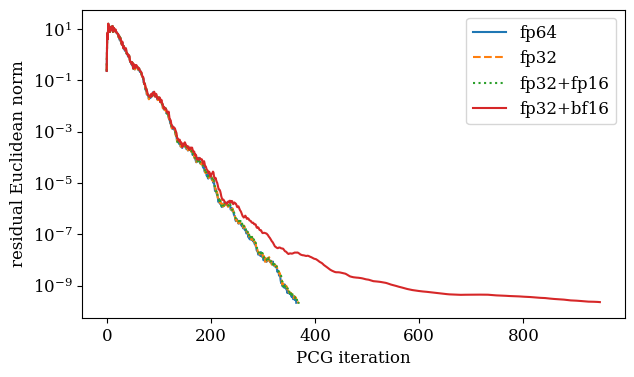

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))

df_prec = df.apply(lambda row: solver_name_to_precision(row["solver"]), axis=1)
line_styles = ["-", "--", ":", "-"]
for i, prec in enumerate(precisions):
    res_norms = ast.literal_eval(
        df[
            (df["p"] == 5)
            & (df["coarse m"] == 6)
            & (df["solver"].str.contains("CG"))
            & (df_prec == prec)
        ].iloc[0]["metadata"]
    )["residual norms"]
    ax.plot(res_norms, label=shorten_precision(prec), linestyle=line_styles[i])

ax.set_yscale("log")
ax.legend(loc="upper right")
ax.set_xlabel("PCG iteration")
ax.set_ylabel("residual Euclidean norm")
fig.savefig("../docs/thesis-media/precision_residuals.svg", bbox_inches="tight")

## Numbers

In [13]:
def get_speedup(what: str, prec: str, base="float64"):
    return summary[(what, base)] / summary[(what, prec)]

In [14]:
get_speedup("cg time", "float32+float16", base="float32")

p  fine m  coarse m
1  10      8           1.097865
           9           1.010775
           10          0.998837
3  9       7           1.207015
           8           1.047074
           9           0.999175
5  8       6           1.279191
           7           1.101839
           8           1.018533
dtype: float64